In [75]:
!pip install pydub

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import plotly.express as px
from scipy.signal import find_peaks
import os
from pydub import AudioSegment


# custom functions to perfomr Leq and db sum
def sum_levels(levels):
    l = np.array(levels)
    return 10*np.log10(np.sum(np.power(10,l/10)))

def leq(levels):
    l = np.array(levels)
    return 10*np.log10(np.mean(np.power(10,l/10)))

def save_peak_clips(df, audio_folder, output_folder):
    for index, row in df.iterrows():
        # Construct full file path
        audio_file_path = os.path.join(audio_folder, row['filename'])

        # Load audio file
        audio = AudioSegment.from_file(audio_file_path)

        # Calculate clip start and end in milliseconds
        start_time = row['peak_start_time'] * 1000  # converting seconds to milliseconds
        end_time = row['peak_end_time'] * 1000      # converting seconds to milliseconds

        # Extract the clip
        clip = audio[start_time:end_time]

        # Create a filename for the clip
        clip_filename = f"clip_{index}.wav"
        clip_path = os.path.join(output_folder, clip_filename)

        # Export the clip
        clip.export(clip_path, format="wav")

        print(f"Saved: {clip_path}")

c:\Users\scjaa\anaconda3\envs\tensorflow_gpu_11_2\lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [80]:
# opne csv file
csv_file = r"\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\SPL\leq_levels_P1_CONTENEDORES_v1_1_test.csv"
df = pd.read_csv(csv_file)
title = csv_file.split("\\")[-3]
audiomoth_folder = csv_file.replace("5-Resultados","3-Medidas").replace("SPL","AUDIOMOTH")
# remove last item from audio moth folder
audiomoth_folder = "\\".join(audiomoth_folder.split("\\")[:-1])
print(audiomoth_folder)

output_folder = csv_file.split("\\")[:-1]
output_folder = os.path.join(*output_folder, "peak_clips")
os.makedirs(output_folder, exist_ok=True)

print(output_folder)
df['filename'] = df['filename'].apply(lambda x: os.path.join(audiomoth_folder, x))
df

\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\3-Medidas\P1_CONTENEDORES\AUDIOMOTH
192.168.205.117\AAC_Server\PUERTOS\NOISEPORT\20231211_SANTUR\5-Resultados\P1_CONTENEDORES\SPL\peak_clips


,LA,LC,LZ,LAmax,LAmin,filename,date
0,72.07,79.36,79.97,73.09,70.91,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:04:20
1,72.40,79.43,79.86,73.70,71.27,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:04:21
2,72.16,78.31,78.61,73.06,71.27,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:04:22
3,72.38,78.21,78.32,73.86,70.97,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:04:23
4,71.70,77.32,77.41,72.21,71.26,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-11 14:04:24
...,...,...,...,...,...,...,...
714003,70.90,77.58,77.77,73.48,68.05,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 06:21:15
714004,70.41,76.66,76.79,73.97,67.94,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 06:21:16
714005,67.92,74.28,74.41,69.86,66.57,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 06:21:17
714006,68.78,74.67,74.79,71.63,66.69,\\192.168.205.117\AAC_Server\PUERTOS\NOISEPORT...,2023-12-20 06:21:18


In [72]:
# convert date column in datetime
df['date'] = pd.to_datetime(df['date'])

duration = df['date'].iloc[-1] - df['date'].iloc[0]
duration = duration.total_seconds()
print(f"Duration: {duration} seconds, {duration/60} minutes, {duration/3600} hours, {duration/3600/24} days")

la = df['LA'].values
print('\nMax:', np.max(la).round(2))
print('Min:', np.min(la).round(2))

print('\nMediana:', np.median(la).round(2))
print('Promedio:', leq(la).round(2))
print('Standard deviation:', np.std(la).round(2))

print('\nPercentil 98:', np.quantile(la, 0.99).round(2)) # percentil 98 means that 98% of the data is below this value

Duration: 749819.0 seconds, 12496.983333333334 minutes, 208.28305555555556 hours, 8.678460648148148 days

Max: 96.9
Min: 55.77

Mediana: 67.47
Promedio: 72.69
Standard deviation: 5.5

Percentil 98: 82.8


Peak start time 3.95
Peak end time 6.5
Peak start time 8.66
Peak end time 10.53


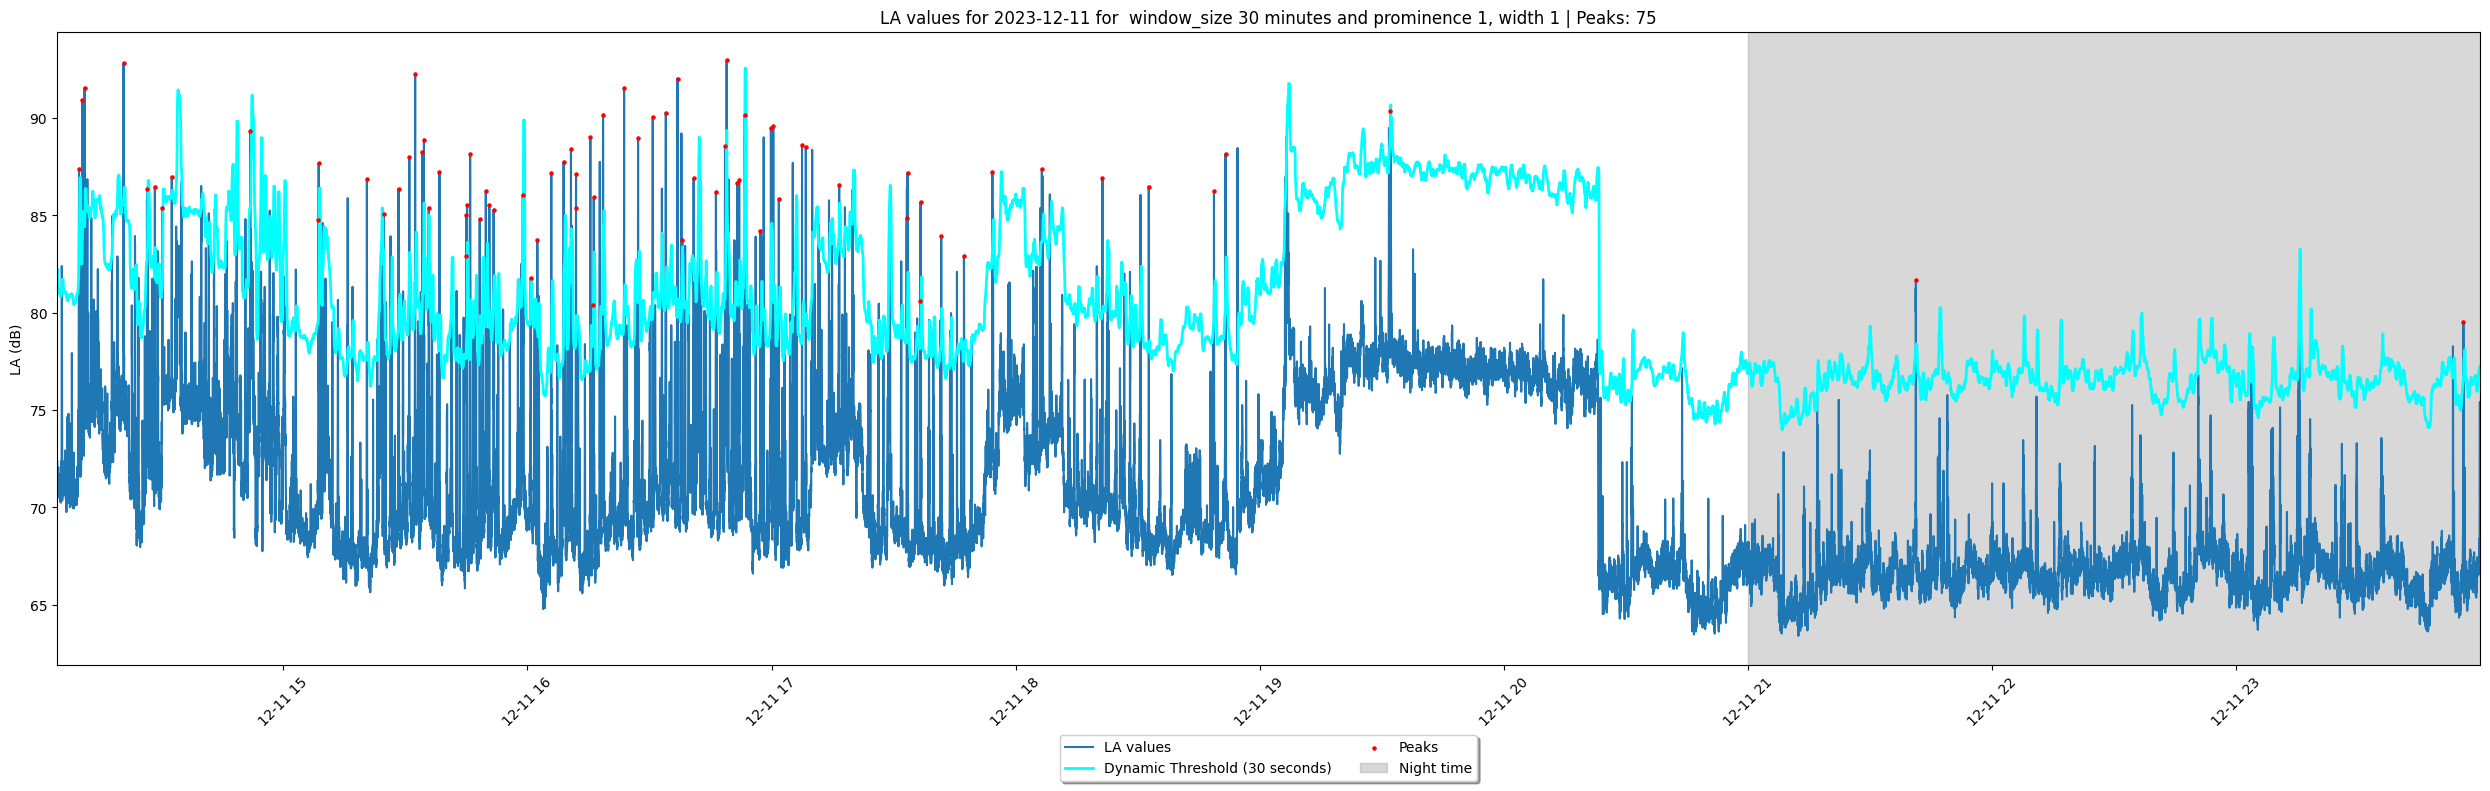

Number of peaks per day: [75]
Peak start time 4.73
Peak end time 6.8
Peak start time 8.71
Peak end time 10.65


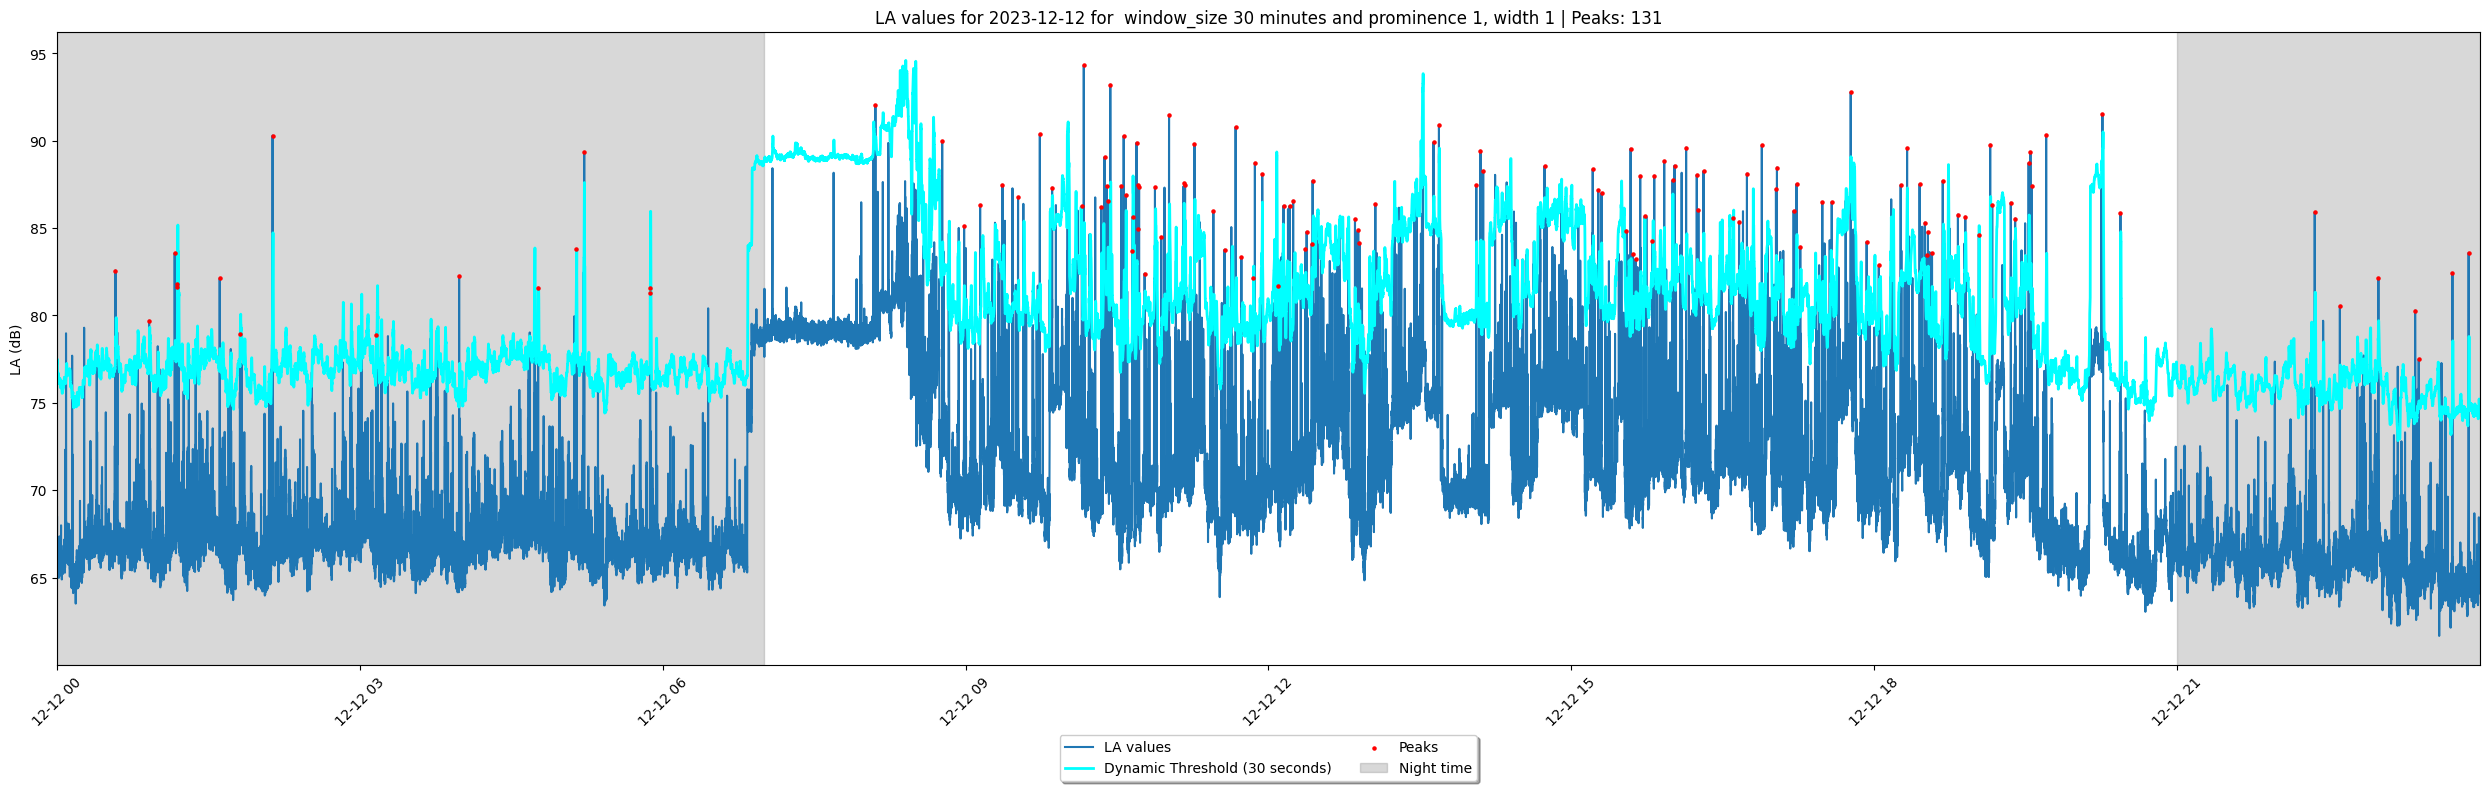

Number of peaks per day: [75, 131]
Peak start time 1.11
Peak end time 3.23
Peak start time 5.38
Peak end time 8.51


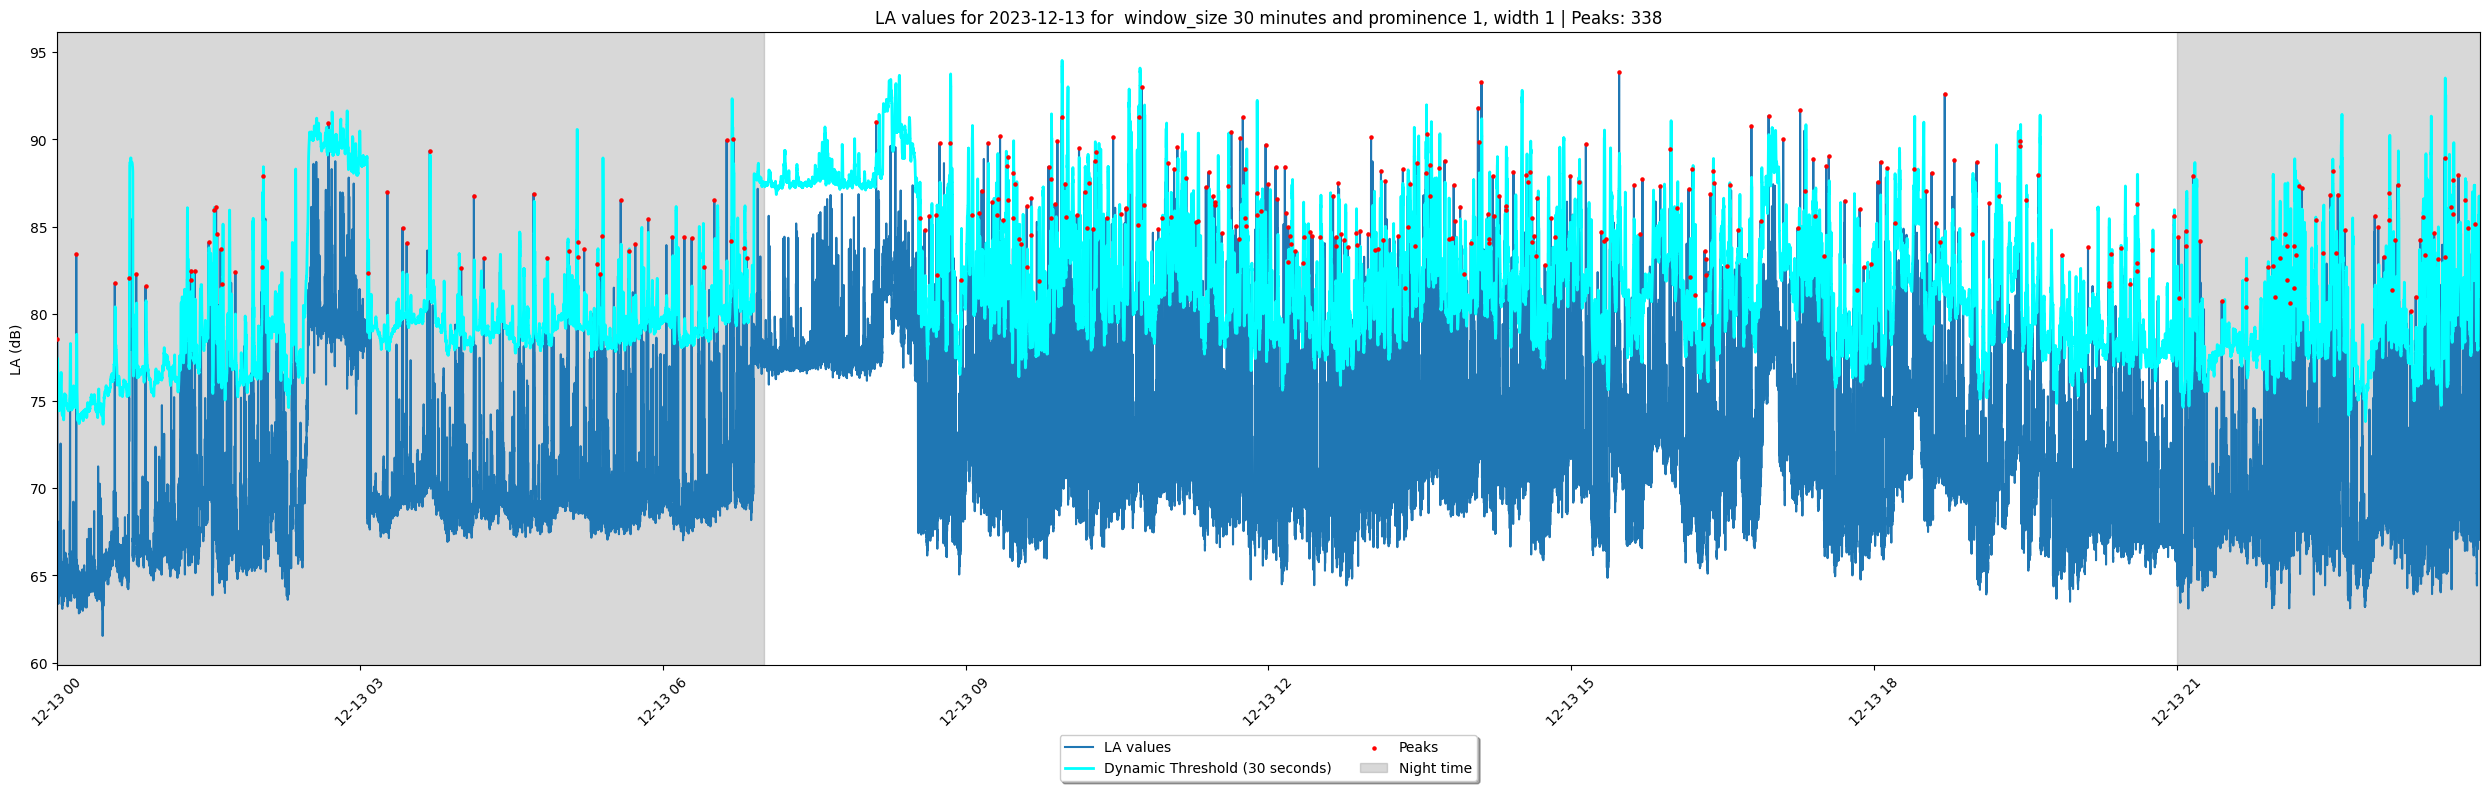

Number of peaks per day: [75, 131, 338]
Peak start time 3.42
Peak end time 4.5
Peak start time 5.6
Peak end time 8.7


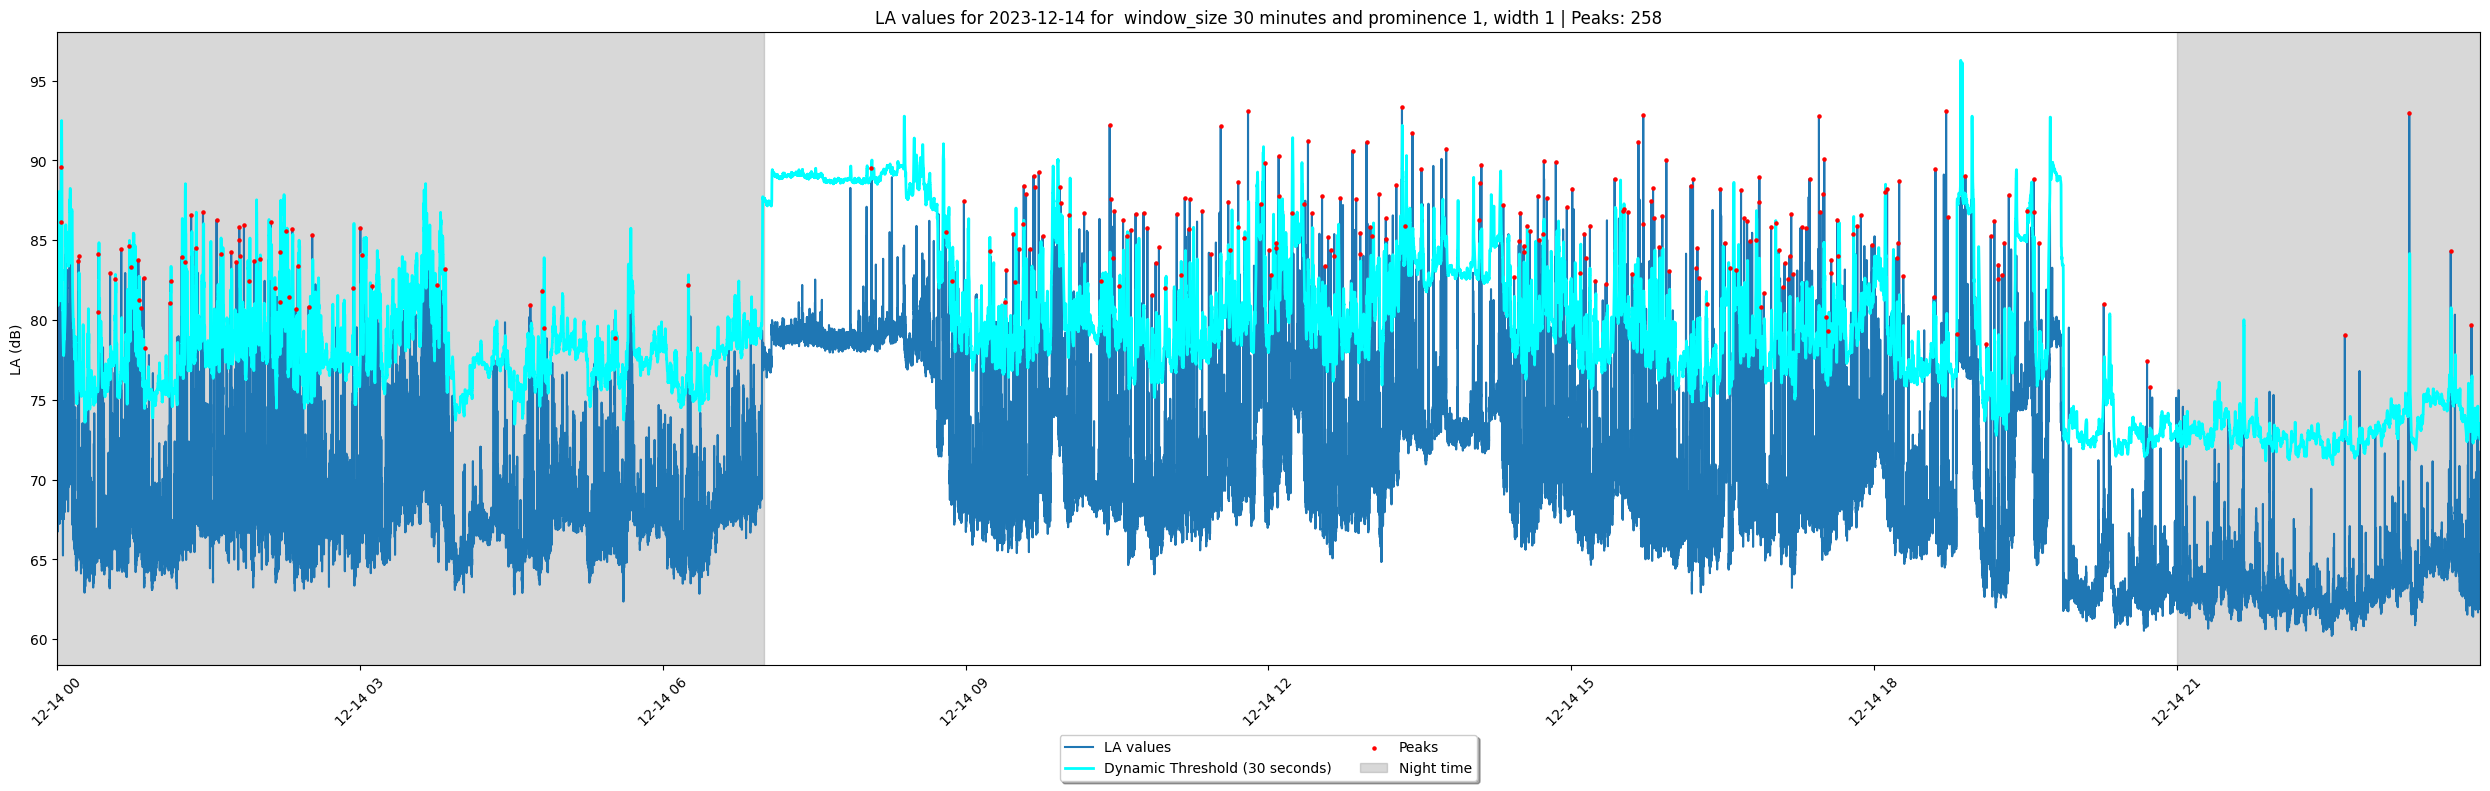

Number of peaks per day: [75, 131, 338, 258]
Peak start time 1.53
Peak end time 3.69
Peak start time 10.1
Peak end time 15.29


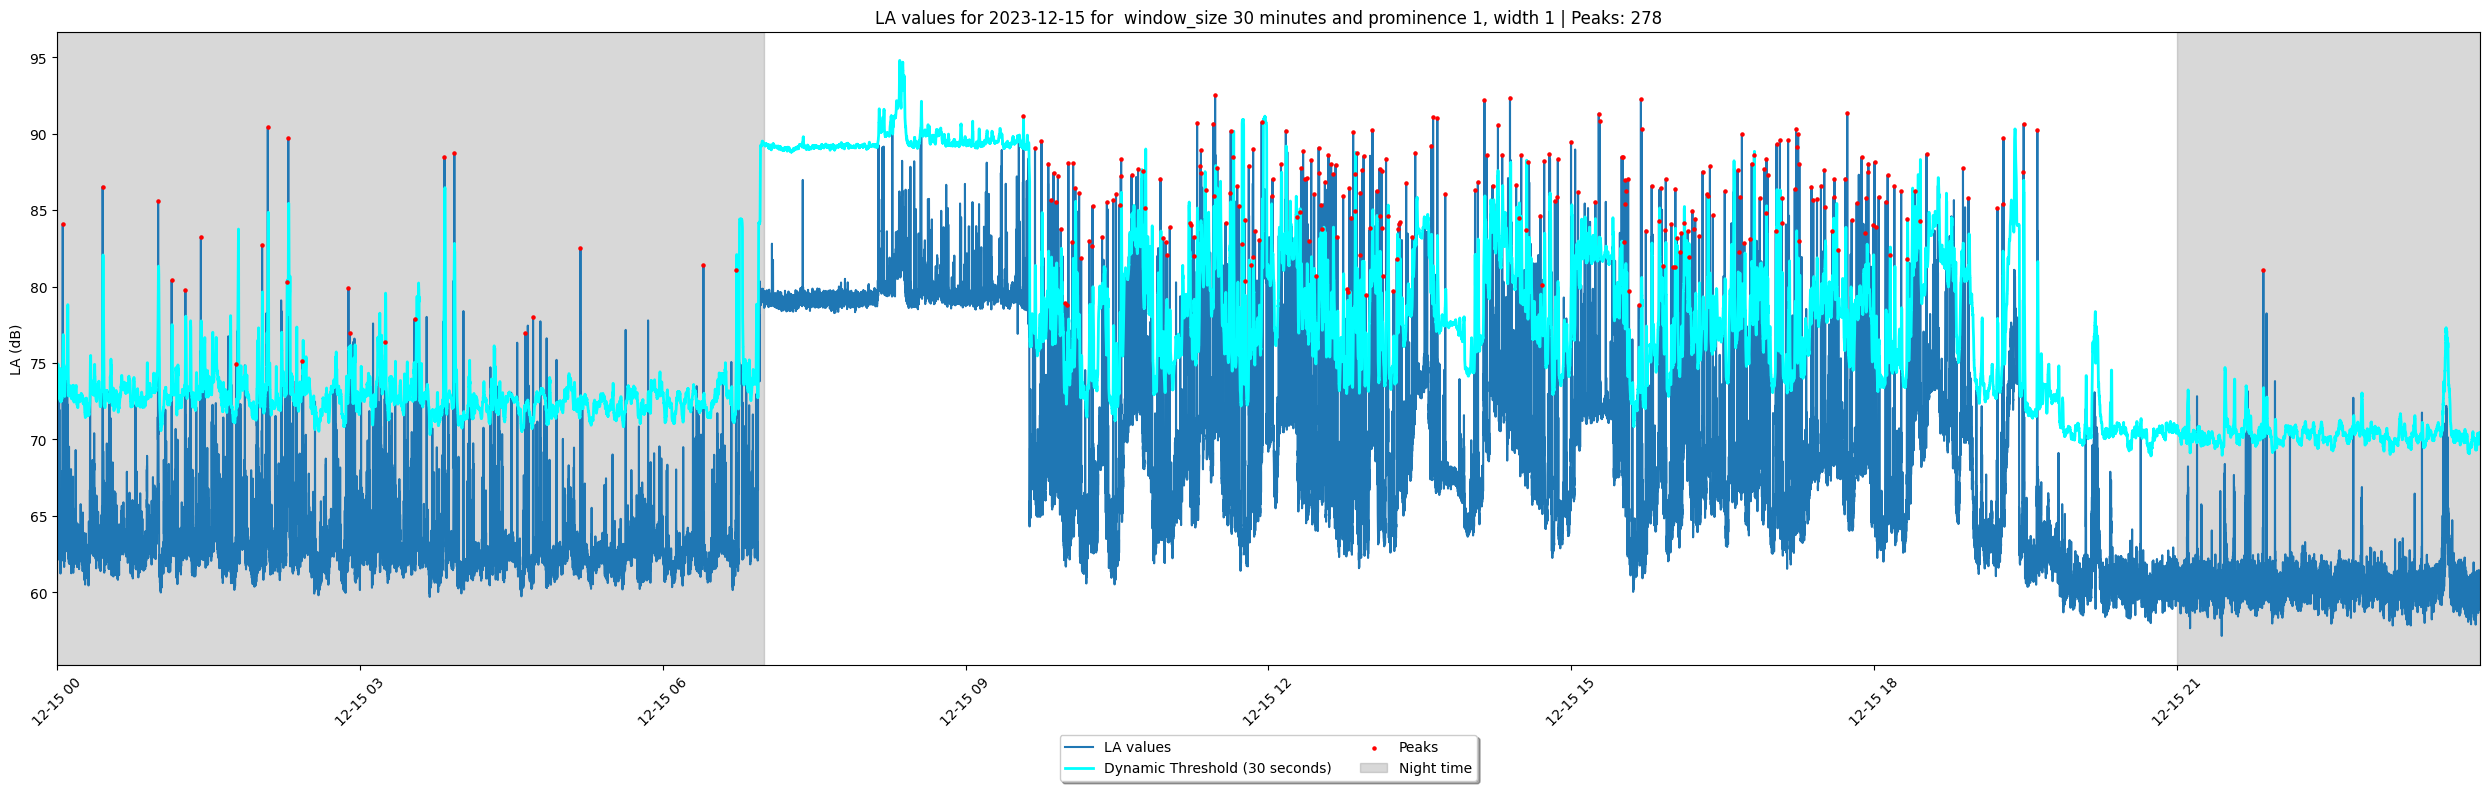

Number of peaks per day: [75, 131, 338, 258, 278]
Peak start time 2.31
Peak end time 4.33
Peak start time 6.42
Peak end time 7.49


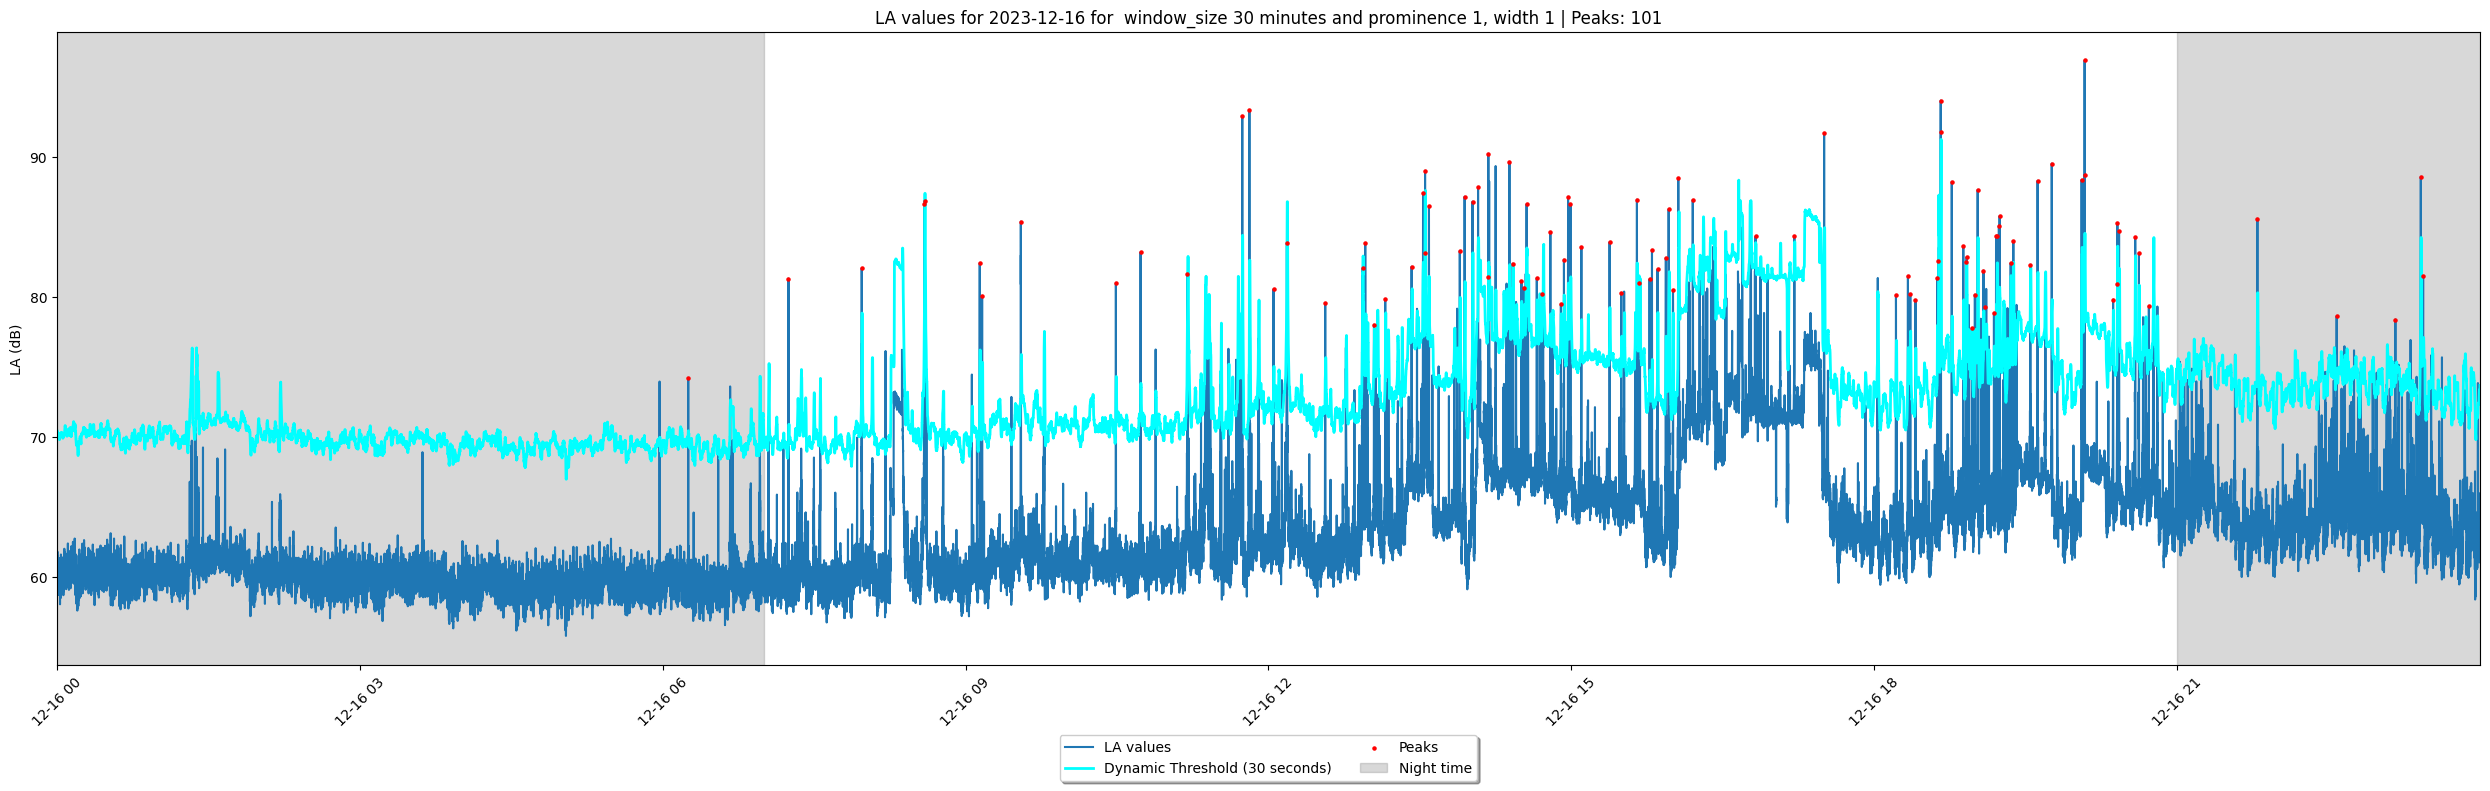

Number of peaks per day: [75, 131, 338, 258, 278, 101]
Peak start time 1.07
Peak end time 4.03
Peak start time 6.87
Peak end time 10.45


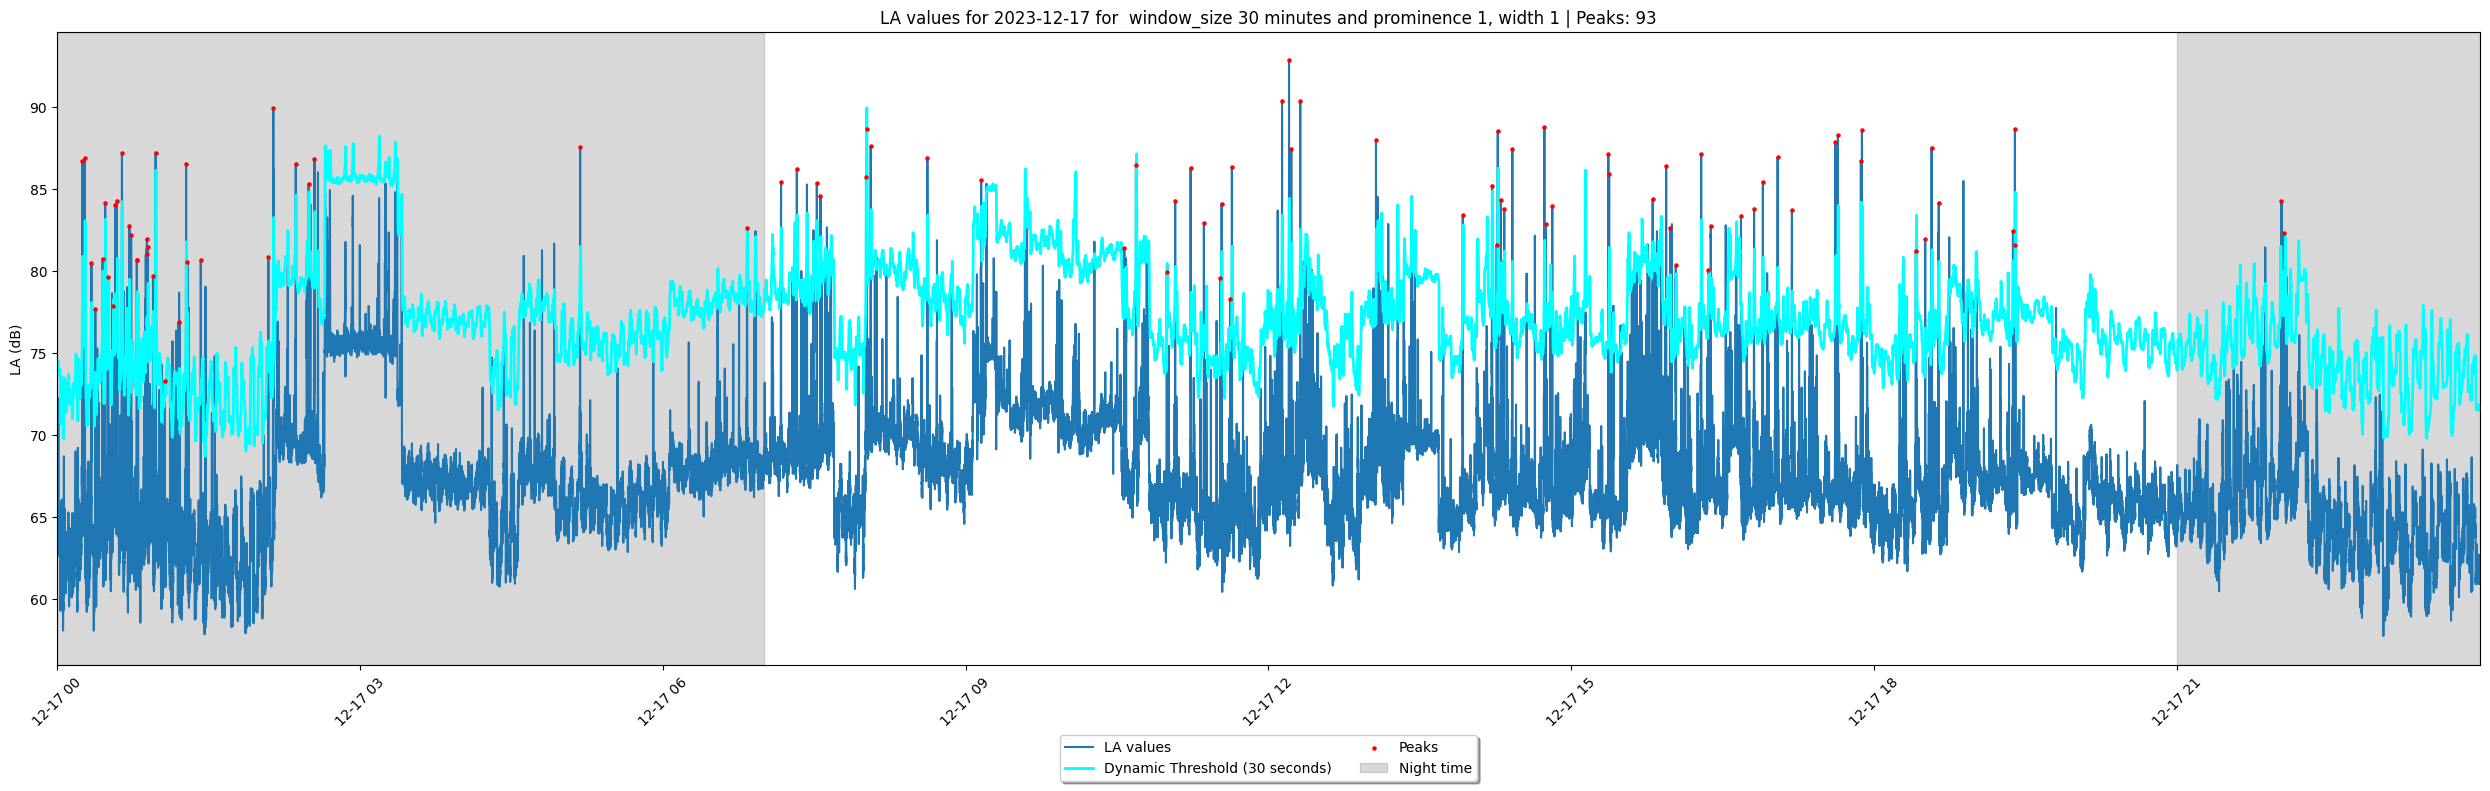

Number of peaks per day: [75, 131, 338, 258, 278, 101, 93]
Peak start time 1.84
Peak end time 3.09
Peak start time 4.96
Peak end time 7.23


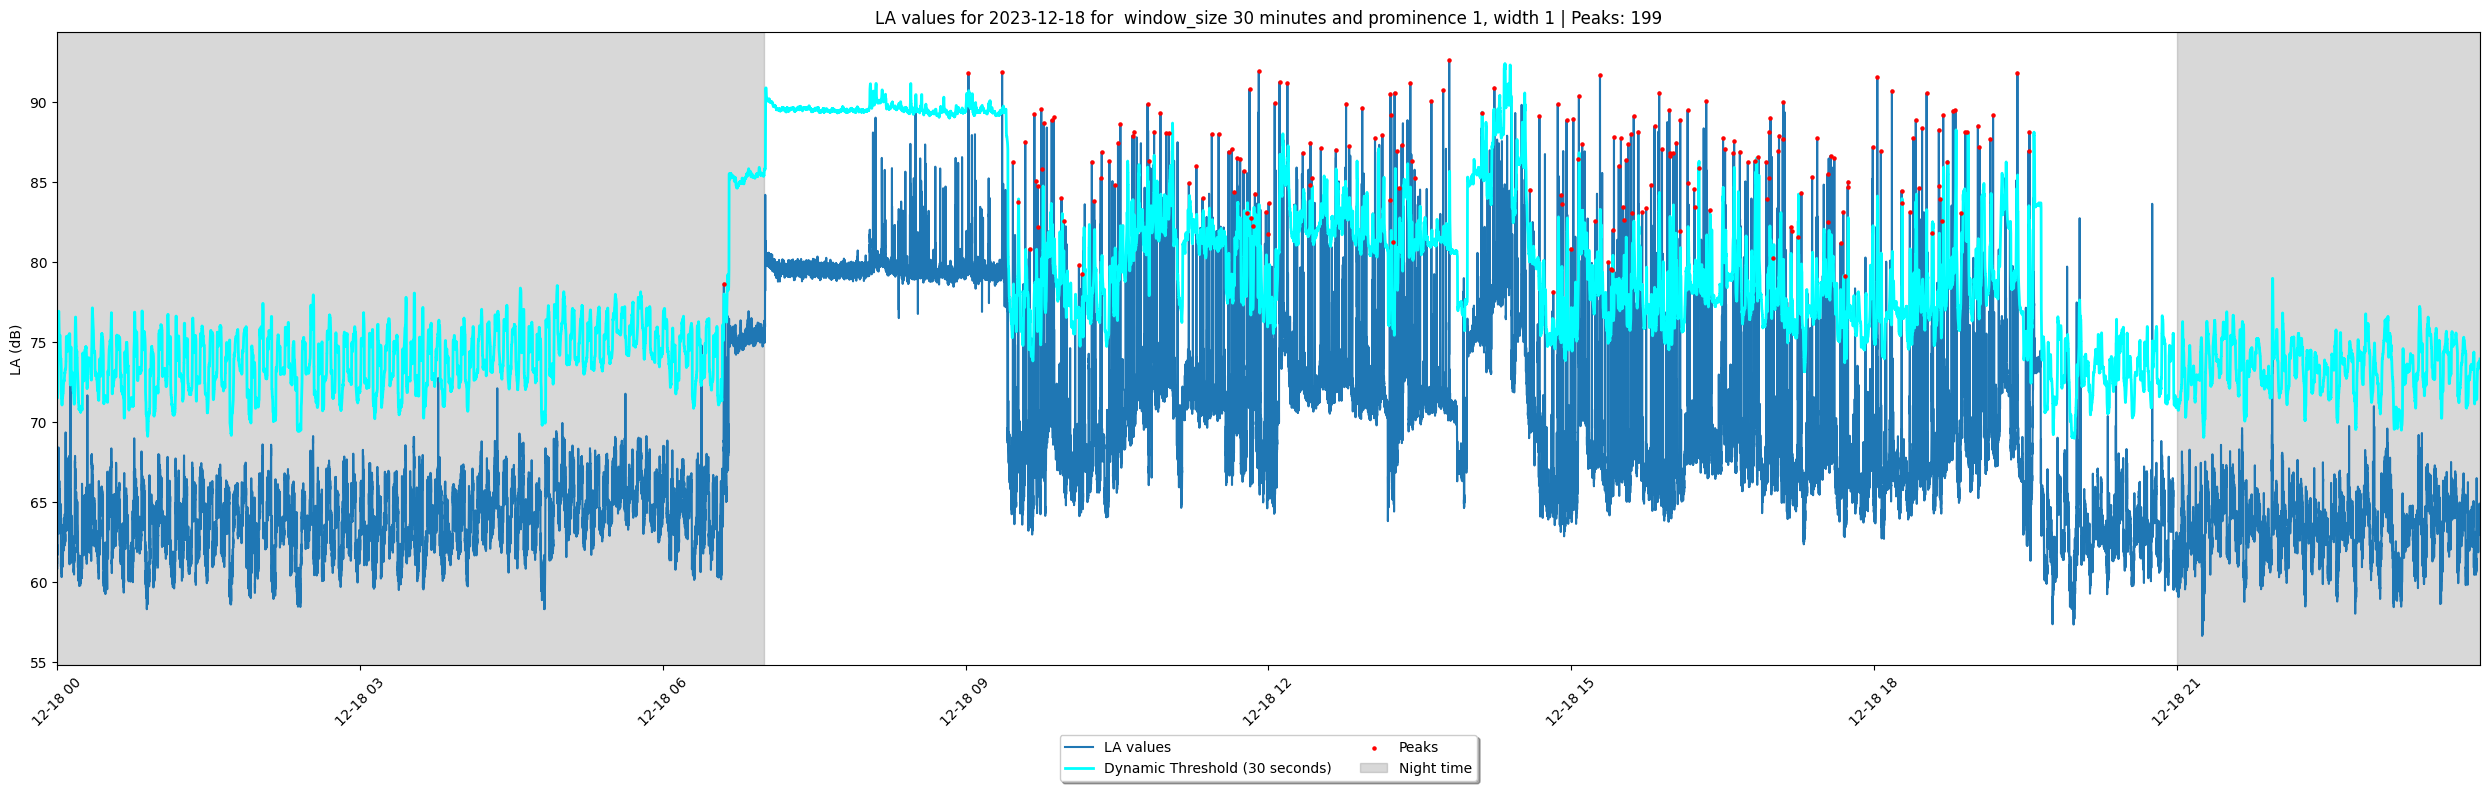

Number of peaks per day: [75, 131, 338, 258, 278, 101, 93, 199]
Peak start time 1.35
Peak end time 2.53
Peak start time 3.5
Peak end time 5.33


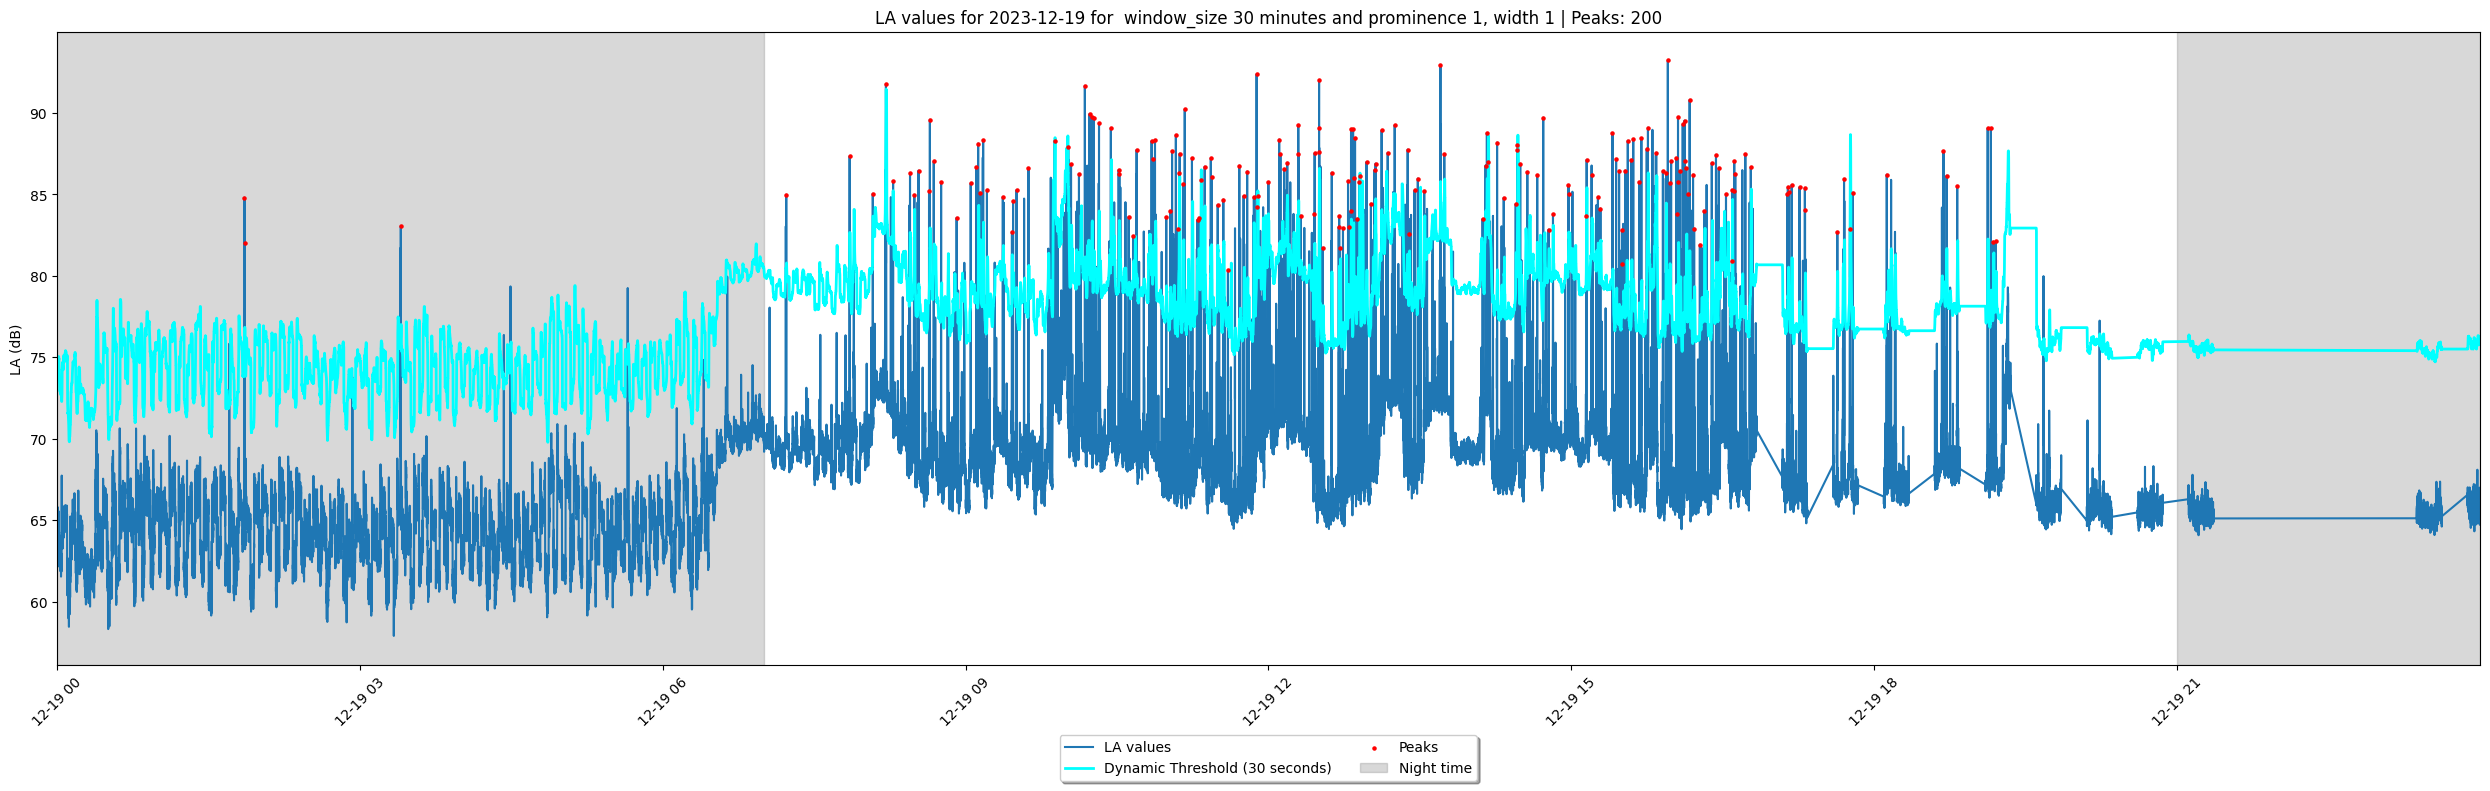

Number of peaks per day: [75, 131, 338, 258, 278, 101, 93, 199, 200]
Peak start time 6.43
Peak end time 9.46
Peak start time 16.28
Peak end time 18.5


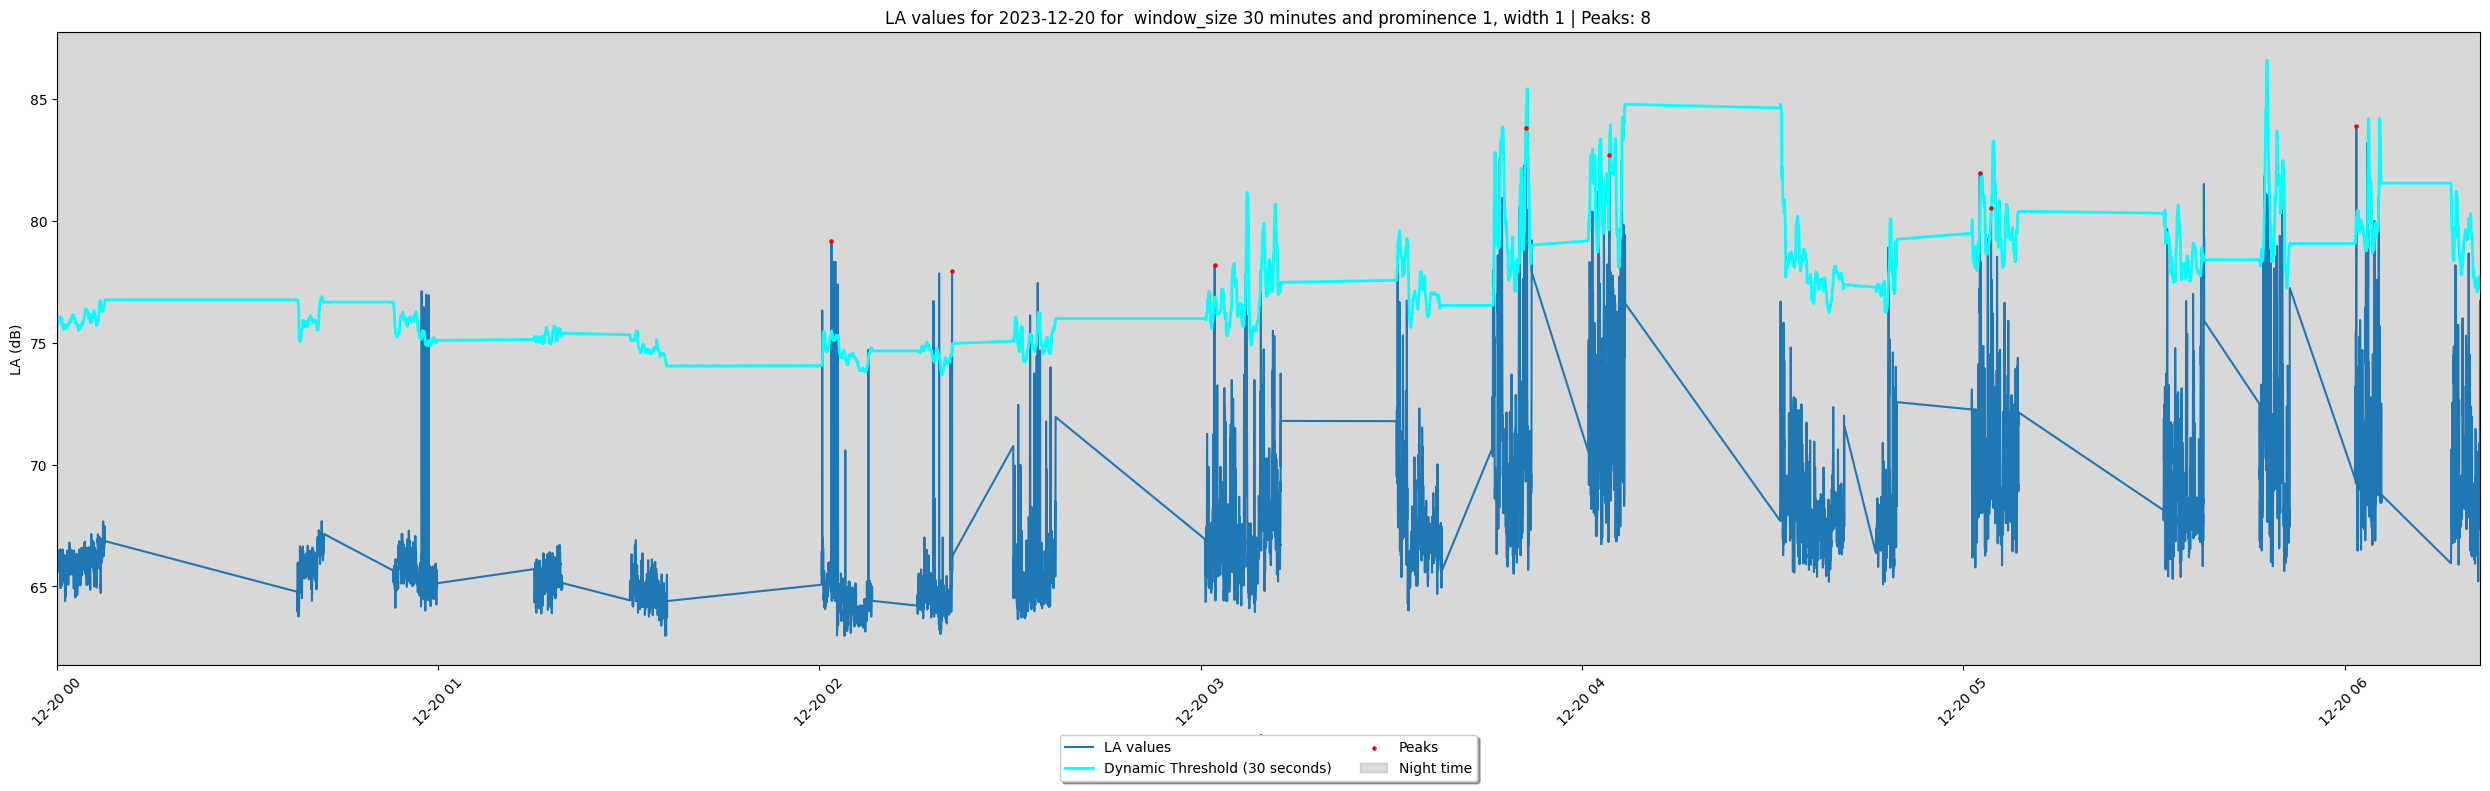

Number of peaks per day: [75, 131, 338, 258, 278, 101, 93, 199, 200, 8]


In [73]:
window_size = 30  # seconds
prominence = 1
width = 1

df['LA_median'] = df['LA'].rolling(window=window_size, min_periods=1).quantile(0.5) + 10

# go through each day
start_date = df['date'].dt.normalize().iloc[0]
end_date = df['date'].dt.normalize().iloc[-1]
current_date = start_date
peaks_num = []
while current_date <= end_date:
    daily_data = df[(df['date'] >= current_date) & (df['date'] < current_date + pd.Timedelta(days=1))]
    
    #dynamic threshold by filtering data points
    above_threshold = daily_data[daily_data['LA'] > daily_data['LA_median']]
    
    #find peaks in the filtered data
    if not above_threshold.empty:
        peaks, properties = find_peaks(above_threshold['LA'], prominence=prominence, width=width)
        
        # extrac audio clip of the peaks
        peak_starts = properties['left_ips']
        peak_ends = properties['right_ips']
        print(f"Peak start time {peak_starts[0].round(2)}")
        print(f"Peak end time {peak_ends[0].round(2)}")

        

        peak_dates = above_threshold['date'].iloc[peaks]
        peak_heights = above_threshold['LA'].iloc[peaks]
        peaks_num.append(len(peak_dates))

    else:
        peak_dates = []
        peak_heights = []

    plt.figure(figsize=(25,8))
    plt.plot(daily_data['date'], daily_data['LA'], label='LA values')
    plt.plot(daily_data['date'], daily_data['LA_median'], color='cyan', linestyle='-', linewidth=2, label=f'Dynamic Threshold ({window_size} seconds)')
    plt.scatter(peak_dates, peak_heights, color='red', s=5, label='Peaks', zorder=5)

    # night time span
    night_start = current_date + pd.Timedelta(hours=21)
    night_end = current_date + pd.Timedelta(hours=24)
    plt.axvspan(night_start, night_end, color='grey', alpha=0.3, label='Night time')

    night_start_2 = current_date + pd.Timedelta(hours=00)
    night_end_2 = current_date + pd.Timedelta(hours=7)
    plt.axvspan(night_start_2, night_end_2, color='grey', alpha=0.3)

    # legend
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), shadow=True, ncol=2)

    plt.xlim(daily_data['date'].iloc[0], daily_data['date'].iloc[-1])
    plt.title(f'LA values for {current_date.date()} for  window_size {window_size} minutes and prominence {prominence}, width {width} | Peaks: {len(peak_dates)}')
    plt.xlabel('Time')
    plt.ylabel('LA (dB)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    current_date += pd.Timedelta(days=1)
    print('Number of peaks per day:', peaks_num)